# 🇮🇷 Persian Digits Recognition with Deep Learning

This notebook implements an end-to-end **Persian handwritten digit recognition system** using **Convolutional Neural Networks (CNNs)**.

The workflow covers:

* Image preprocessing using OpenCV
* Dataset creation and storage
* Train/Test splitting
* CNN architecture design
* Model training
* Classification evaluation
* Confusion Matrix and Classification Report
* Learning curves
* ROC-AUC analysis
* Precision-Recall analysis
* Prediction on unseen images
* Multi-digit number recognition
* Desktop GUI using Tkinter

---

# 1. 📦 Import Required Libraries

In this section, the required libraries for **data processing, image processing, Deep Learning, visualization, evaluation, and GUI development** are imported.

Main libraries used in this project include:

* **NumPy** → numerical operations
* **Pandas** → data handling
* **OpenCV** → image processing
* **TensorFlow / Keras** → CNN development and training
* **Scikit-learn** → dataset splitting and model evaluation
* **Matplotlib / Seaborn** → visualization
* **Tkinter / Pillow** → desktop application


# ⚠️ Limitations

Although the model performs Persian digit classification, several limitations should be considered.

### Dataset Limitations

The model's generalization depends strongly on the diversity and quality of the training dataset.

Images that significantly differ from the training distribution may result in incorrect predictions.

### Image Segmentation

Multi-digit recognition depends on successful contour detection and segmentation.

Touching, overlapping, very small, or noisy digits may make segmentation more difficult.

### Input Format

The CNN expects images with a fixed size of:

```text
32 × 32 × 1
```

Therefore, input images need to go through the same preprocessing pipeline used during training.

### Model Capacity

The current CNN is intentionally relatively lightweight. A deeper architecture could potentially improve recognition performance, especially with a larger and more diverse dataset.


# 🔁 Reproducibility

To make the experiment reproducible, the project separates the workflow into several stages:

```text
Dataset Preparation
        ↓
Preprocessing
        ↓
Dataset Saving
        ↓
Train/Test Split
        ↓
Model Training
        ↓
Evaluation
        ↓
Inference
```

The processed dataset can be saved and reused instead of running the complete image-processing pipeline every time.

For a complete reproduction of the environment, install the dependencies using:

```bash
pip install -r requirements.txt
```

The notebook should then be executed from top to bottom.


# 🛠️ Environment & Dependencies

This project was developed using **Python** and the following libraries:

| Library         | Purpose                                     |
| --------------- | ------------------------------------------- |
| `numpy`         | Numerical operations and array manipulation |
| `pandas`        | Data handling and analysis                  |
| `opencv-python` | Image processing and computer vision        |
| `tensorflow`    | Deep Learning framework                     |
| `keras`         | Neural network API                          |
| `scikit-learn`  | Data splitting and model evaluation         |
| `matplotlib`    | Data visualization                          |
| `seaborn`       | Statistical visualization                   |
| `Pillow`        | Image loading and manipulation              |
| `tkinter`       | Desktop graphical user interface            |

### Python Environment

Recommended Python version:

```text
Python 3.10+
```

> The exact package versions should be pinned in `requirements.txt` when preparing the repository for reproducibility.


In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import cv2
import os
# added for splitting the dataset into training and testing sets
from sklearn.model_selection import train_test_split
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten

# added for evaluation
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import precision_recall_curve

%matplotlib widget

import tkinter as tk
from PIL import Image, ImageTk



# 3. 🖼️ Image Preprocessing and Dataset Creation

Each image is processed before being passed to the neural network.

The preprocessing pipeline is:

```text
Original Image
      ↓
Grayscale Conversion
      ↓
Resize to 32 × 32
      ↓
Image Inversion
      ↓
Normalization
      ↓
Store Image + Label
```

### Preprocessing steps

**1. Grayscale**

Color information is not required for digit recognition, so each image is converted to grayscale.

**2. Resize**

All images are resized to:

```text
32 × 32
```

This guarantees a consistent input size for the CNN.

**3. Image Inversion**

The pixel values are inverted so that the digit representation is consistent with the training data.

**4. Normalization**

Pixel values are divided by `255`, converting the range from:

```text
0 – 255
```

to:

```text
0 – 1
```

This makes the input more suitable for neural network training.

Finally, the processed images and their labels are converted into NumPy arrays.

---

In [2]:

data1 = "./dataset/"

dimension = []
label = []
file = os.listdir(data1)

In [ ]:
# Create dataset
for folder in file :
   folder_all = os.path.join(data1, folder)

   for pic in os.listdir(folder_all):
      pic_all = os.path.join(folder_all, pic)
      im = cv2.imread(pic_all)

      im2 = cv2.cvtColor(im,cv2.COLOR_BGR2GRAY)

      im3 = cv2.resize(im2,(32,32))
      
      im4 = cv2.bitwise_not(im3)

      im5 = im4 / 255

      dimension.append(im5)

      label.append(int(folder))

x = np.array(dimension)
y = np.array(label)

print("dimention shape:", x.shape)
print("label shape:", y.shape)


# 4. 🔎 Dataset Shape

Here we inspect the dimensions of the image and label arrays.

The image array contains the processed digit images, while the label array contains the corresponding classes from `0` to `9`.

Checking the shapes at this stage helps verify that the dataset has been loaded and constructed correctly.

---

In [ ]:
x.shape,y.shape

((80000, 32, 32), (80000,))

# 5. 💾 Save the Processed Dataset

Instead of repeating the image preprocessing pipeline every time, the processed dataset is stored in a compressed `.npz` file.

```text
persian_digits_dataset.npz
```

This allows the processed dataset to be quickly reused in future experiments.

---

In [ ]:
# Save Dataset
np.savez_compressed(
    "persian_digits_dataset.npz",
    x=x,
    y=y
)

print("Dataset saved successfully.")

# 6. 📂 Load the Dataset

The previously saved `.npz` file is loaded using NumPy.

The stored arrays are extracted as:

```python
x → images
y → labels
```

This separates the dataset preparation stage from the model training stage.

---

In [3]:
# Loading dataset
data = np.load("persian_digits_dataset.npz")

x = data["x"]
y = data["y"]

print(x.shape)
print(y.shape)

(80000, 32, 32)
(80000,)


# 7. ✂️ Train/Test Split

The dataset is divided into two subsets:

```text
80% → Training Set
20% → Test Set
```

The **training set** is used to learn the visual patterns of Persian digits.

The **test set** is kept separate and is used to evaluate the model on unseen samples.

---


In [4]:
# splitting the dataset into training and testing sets
x_train,x_test, y_train,y_test = train_test_split(x , y , train_size=0.8 , test_size= 0.2)

In [5]:
print("x train: ", x_train.shape)
print("x test: ", x_test.shape)
print("y train: ", y_train.shape)
print("y test: ", y_test.shape)

x train:  (64000, 32, 32)
x test:  (16000, 32, 32)
y train:  (64000,)
y test:  (16000,)


# 8. 🧩 Prepare Data for Conv2D

A CNN expects image data in the following format:

```text
Height × Width × Channels
```

Because the images are grayscale, they contain only one channel:

```text
32 × 32 × 1
```

An additional axis is therefore added to the training and test arrays to make them compatible with the `Conv2D` layer.

---


In [6]:
# Apending a new axis to the data to make it compatible with Conv2D layer
x_train = np.expand_dims(x_train,axis=3)
x_test = np.expand_dims(x_test,axis=3)
x_test.shape

(16000, 32, 32, 1)

# 9. 👀 Visualize a Sample

Before training the model, one sample from the training dataset is visualized.

This provides a quick sanity check to confirm that:

* The image was loaded correctly.
* The preprocessing pipeline worked as expected.
* The digit and its corresponding label are consistent.

---

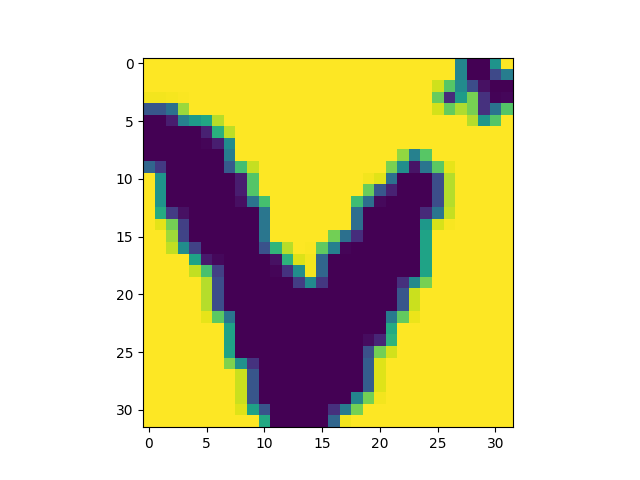

np.int64(7)

In [7]:
plt.close
plt.imshow(x_train[0])
plt.show()
y_train[0]

# 10. 🧠 Build the Convolutional Neural Network

A **Convolutional Neural Network (CNN)** is used because digit recognition is an image classification problem.

The architecture consists of:

```text
Input: 32 × 32 × 1
        ↓
Conv2D
9 Filters
3 × 3 Kernel
ReLU
        ↓
MaxPooling
2 × 2
        ↓
Flatten
        ↓
Dense(32)
ReLU
        ↓
Dense(16)
ReLU
        ↓
Dense(10)
        ↓
Digit Classes 0–9
```

The final layer contains **10 output neurons**, one for each Persian digit class.

The model summary is displayed to inspect the architecture and number of trainable parameters.

---

In [8]:
# Create model

model = Sequential()
model.add(Conv2D(filters=9, kernel_size=(3,3), activation='relu', input_shape=(32,32,1)))
model.add(MaxPooling2D((2,2)))
model.add(Flatten())
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(10))

model.summary()

C:\Users\HP\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 9)      │            90 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 9)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2025)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │        64,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,620 (256.33 KB)

 Trainable params: 65,620 (256.33 KB)

 Non-trainable params: 0 (0.00 B)

# 11. 🎨 Visualize the Model Architecture

This optional section creates a visual representation of the CNN architecture.

It is useful for understanding how the input image moves through the different layers of the neural network.

> This step is only for visualization and does not affect model training.

---


In [9]:
# this code is not necessary 
# this is for visualizing the model
from keras_visualizer import visualizer


visualizer(model,file_name="Model_Persian_Numbers",file_format='png')

# 12. ⚙️ Compile the Model

The CNN is compiled using:

* **Adam** optimizer
* **Sparse Categorical Crossentropy** loss
* **Accuracy** as the evaluation metric

`from_logits=True` is used because the final `Dense(10)` layer does not contain a Softmax activation.

The model therefore outputs raw class scores, known as **logits**.

---

In [10]:
model.compile(optimizer='adam' , loss= tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=['accuracy'])

# 13. 🚀 Train the CNN

The model is trained for **25 epochs**.

During training, the model learns visual patterns that distinguish the ten digit classes.

Validation data is provided during training so that the model's performance on unseen samples can be monitored after each epoch.

The training history is stored in the variable `h`.

---

In [11]:
h = model.fit(x_train,y_train,epochs= 25,validation_data=(x_test,y_test))

Epoch 1/25
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - accuracy: 0.9262 - loss: 0.2402 - val_accuracy: 0.9731 - val_loss: 0.0899
Epoch 2/25
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9773 - loss: 0.0780 - val_accuracy: 0.9722 - val_loss: 0.0922
Epoch 3/25
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9831 - loss: 0.0580 - val_accuracy: 0.9828 - val_loss: 0.0570
Epoch 4/25
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9865 - loss: 0.0443 - val_accuracy: 0.9829 - val_loss: 0.0539
Epoch 5/25
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9891 - loss: 0.0361 - val_accuracy: 0.9848 - val_loss: 0.0531
Epoch 6/25
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9906 - loss: 0.0299 - val_accuracy: 0.9865 - val_loss: 0.0444
Epoch 7/25
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9927 - loss: 0.0228 - val_accuracy: 0.9838 - val_loss: 0.0569
Epoch 8/25
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9937 - loss: 0

# 14. 📜 Inspect Training History

The training history contains information recorded during training, including:

```text
accuracy
val_accuracy
loss
val_loss
```

These values are later used to analyze the learning behavior of the CNN.

---

In [12]:
print(h.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


# 15. 🎯 Evaluate the Model

After training, the model is evaluated on the test dataset.

Two main values are obtained:

```text
Loss
Accuracy
```

The test set represents unseen data, so this evaluation provides an indication of how well the trained model generalizes beyond the training samples.

---

In [13]:
# 1 / Evalution model
loss, accuracy = model.evaluate(x_test, y_test)

print("Loss :", loss)
print("Accuracy :", accuracy)

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9889 - loss: 0.0579
Loss : 0.05794980004429817
Accuracy : 0.9888749718666077


# 16. 🔮 Generate Predictions

The trained CNN is used to generate predictions for all test images.

Because the final layer produces logits, the output contains a score for each of the ten possible classes.

The result has the conceptual structure:

```text
Image
  ↓
CNN
  ↓
10 Class Scores
  ↓
Digit Prediction
```

---

In [14]:
# Predicting the labels for the test set by logits
labels_logits = model.predict(x_test)


500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


# 17. 📊 Inspect Model Outputs

The raw model outputs are displayed here.

Each test image receives ten values corresponding to the model's scores for:

```text
0, 1, 2, 3, 4, 5, 6, 7, 8, 9
```

The highest score represents the model's predicted class.

---

In [15]:
# this show answer by persent
labels_logits 

array([[ -7.078925 , -12.215698 ,  18.252527 , ...,  -4.1023393,
        -40.028698 , -34.60993  ],
       [-37.246967 ,  -8.31579  ,  -6.1548004, ..., -33.35108  ,
        -13.2612915,  11.518253 ],
       [-12.2156725,   5.3002977,  17.728622 , ...,  -0.8421338,
        -35.547043 , -20.559904 ],
       ...,
       [ -6.2328944,  20.897654 ,  -9.98597  , ..., -13.07221  ,
         -8.7709675, -11.80773  ],
       [ 23.571926 ,   5.568531 , -18.081085 , ...,  -2.6971853,
         -7.887409 , -11.508736 ],
       [ -1.0016452, -19.677858 , -33.13202  , ..., -36.695137 ,
        -12.60598  , -30.587786 ]], shape=(16000, 10), dtype=float32)

# 18. 🔢 Convert Logits to Predicted Classes

`argmax` is used to select the class with the highest predicted score.

For each image:

```text
10 scores
    ↓
Highest score
    ↓
Predicted digit
```

The resulting array contains the predicted digit for every test sample.

---

In [16]:
# I become it to singel number that each number shows The possibilities.
# In fact we ready for accuracy_score(test_labels, out) and so on.....
out = np.argmax(labels_logits, axis=1)
out

array([2, 9, 2, ..., 1, 0, 5], shape=(16000,))

# 19. ✅ Accuracy Score

The predicted labels are compared with the true test labels using `accuracy_score`.

Accuracy represents the proportion of test images that were classified correctly.

```text
Accuracy =
Correct Predictions / Total Predictions
```

---

In [17]:
# Accuracy_score
accuracy_score(y_test, out)

0.988875

# 20. 🔲 Confusion Matrix

A confusion matrix provides a more detailed view of classification performance.

Rows represent the **true labels**, while columns represent the **predicted labels**.

The diagonal values correspond to correctly classified digits.

Off-diagonal values show where the model confused one digit with another.

---

In [18]:
# Confusion_matrix

cm = confusion_matrix(y_test, out)
print(cm)

[[1571    2    1    0    1    8    0    1    0    0]
 [   6 1622    1    1    2    0    1    0    1    0]
 [   0    4 1509   32    3    0    1    1    0    1]
 [   0    0   12 1596    7    0    3    1    0    0]
 [   0    0    3    7 1531    2    1    0    0    2]
 [   6    0    1    0    6 1680    0    1    3    0]
 [   0    2    3    3    1    3 1557    2    0   18]
 [   0    2    1    2    1    1    1 1589    0    0]
 [   0    3    0    0    1    1    1    0 1590    1]
 [   1    0    0    1    1    0    5    0    1 1577]]


# 21. 📊 Visualize the Confusion Matrix

The confusion matrix is visualized as a heatmap to make classification patterns easier to interpret.

This visualization helps identify which Persian digits are easier or more difficult for the CNN to distinguish.

---

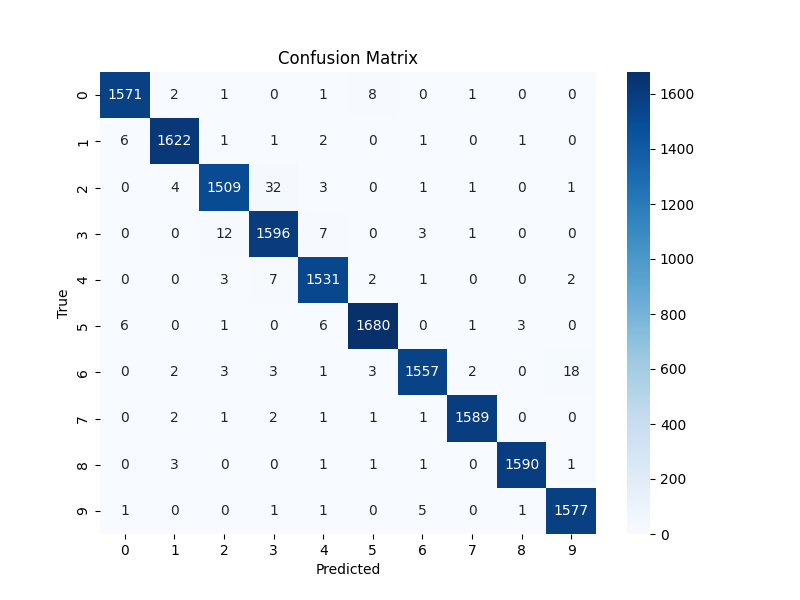

In [19]:
# Confusion matrix visualization
plt.figure(figsize=(8,6))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# 22. 📋 Classification Report

The classification report provides detailed metrics for each digit class:

* **Precision**
* **Recall**
* **F1-score**
* **Support**

This gives a more complete evaluation than accuracy alone.

---

In [20]:
# 5 /Classification Report
print(classification_report(y_test, out))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1584
           1       0.99      0.99      0.99      1634
           2       0.99      0.97      0.98      1551
           3       0.97      0.99      0.98      1619
           4       0.99      0.99      0.99      1546
           5       0.99      0.99      0.99      1697
           6       0.99      0.98      0.99      1589
           7       1.00      0.99      1.00      1597
           8       1.00      1.00      1.00      1597
           9       0.99      0.99      0.99      1586

    accuracy                           0.99     16000
   macro avg       0.99      0.99      0.99     16000
weighted avg       0.99      0.99      0.99     16000



# 📈 Model Performance

The following sections analyze how the CNN behaved during training and how well it performs on unseen data.

---

# 23. 📈 Accuracy Curve

The training and validation accuracy are plotted over the training epochs.

This curve helps analyze:

* Learning progress
* Generalization
* Training stability
* Possible overfitting

A large difference between training and validation accuracy can be an indication of overfitting.

---

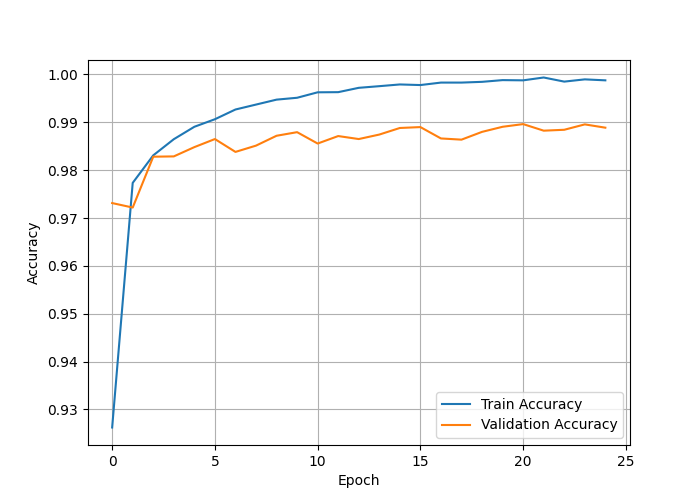

In [21]:
# Accuracy
plt.figure(figsize=(7,5))

plt.plot(h.history["accuracy"],label="Train Accuracy")

plt.plot(h.history["val_accuracy"],label="Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.grid()

plt.show()

# 24. 📉 Loss Curve

The training and validation loss are plotted across epochs.

Loss represents how far the model's predictions are from the expected labels according to the selected loss function.

Comparing training and validation loss helps evaluate the model's learning behavior and generalization.

---


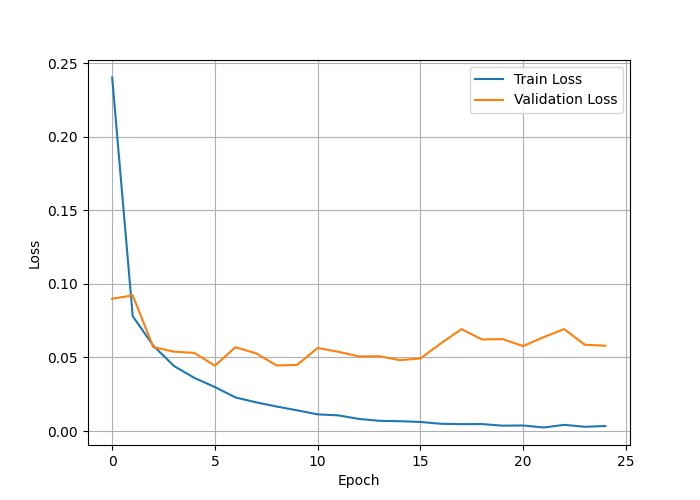

In [22]:
# 7/ Learning Curves 
plt.figure(figsize=(7,5))

plt.plot(h.history["loss"],label="Train Loss")

plt.plot(h.history["val_loss"],label="Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid()

plt.show()

# 25. 🎲 Class Probabilities

The model initially produces **logits**, not probabilities.

Softmax is applied to convert these logits into normalized class probabilities.

For each image:

```text
10 logits
    ↓
Softmax
    ↓
10 probabilities
    ↓
Sum ≈ 1
```

These probabilities are required for probability-based evaluation such as ROC-AUC and Precision-Recall analysis.

---

In [23]:
# probability of each class for each sample in the test set
# prepering the labels for ROC-AUC
out_pro = tf.nn.softmax(labels_logits).numpy()
out_pro

array([[9.7677014e-12, 5.7401038e-14, 9.7971982e-01, ..., 1.9164915e-10,
        4.7850515e-26, 1.0795144e-23],
       [6.6302944e-22, 2.4332312e-09, 2.1119773e-08, ..., 3.2620779e-20,
        1.7313281e-11, 9.9999762e-01],
       [9.8936491e-14, 4.0035502e-06, 9.9999571e-01, ..., 8.6063867e-09,
        7.2890464e-24, 2.3523476e-17],
       ...,
       [1.6495007e-12, 1.0000000e+00, 3.8673454e-14, ..., 1.7663452e-15,
        1.3034116e-13, 6.2550749e-15],
       [1.0000000e+00, 1.5178362e-08, 8.1344290e-19, ..., 3.9036400e-12,
        2.1746248e-14, 5.8165070e-16],
       [1.7761195e-18, 1.3756076e-26, 1.9743737e-32, ..., 5.5973648e-34,
        1.6209634e-23, 2.5140469e-31]], shape=(16000, 10), dtype=float32)

# 26. 📐 Multi-Class ROC-AUC

Because this is a ten-class classification problem, the labels are converted into a binary representation using `label_binarize`.

ROC-AUC is then calculated using the **One-vs-Rest (OvR)** strategy.

This provides an additional evaluation of how well the model separates each digit class from the remaining classes.

---

In [24]:
# ROC-AUC
test_label_bin = label_binarize(
    y_test,
    classes=np.arange(10)
)

auc = roc_auc_score(
    test_label_bin,
    out_pro,
    multi_class="ovr"
)

print(auc)

0.9998783890801468


# 27. 📉 ROC Curve

The ROC curve is generated for **Class 0**.

It compares:

```text
True Positive Rate
        vs.
False Positive Rate
```

The curve provides a visual representation of the model's ability to distinguish the selected digit from the other classes.

---

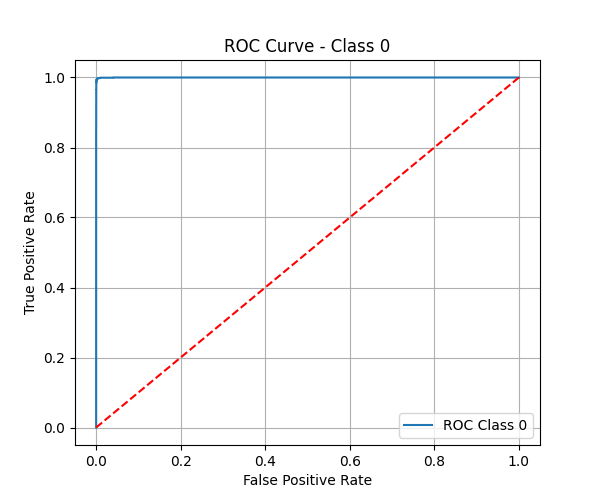

In [25]:
# roc_curve
fpr, tpr, thresholds = roc_curve(
    test_label_bin[:,0],
    out_pro[:,0]
)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label="ROC Class 0")

plt.plot([0,1],[0,1],'--',color='red')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Class 0")

plt.legend()

plt.grid()

plt.show()

# 28. 🎯 Precision-Recall Curve

The Precision-Recall curve is also calculated for a selected digit class.

It shows the relationship between:

```text
Precision
    vs.
Recall
```

This provides another perspective on the model's classification behavior for an individual class.

---

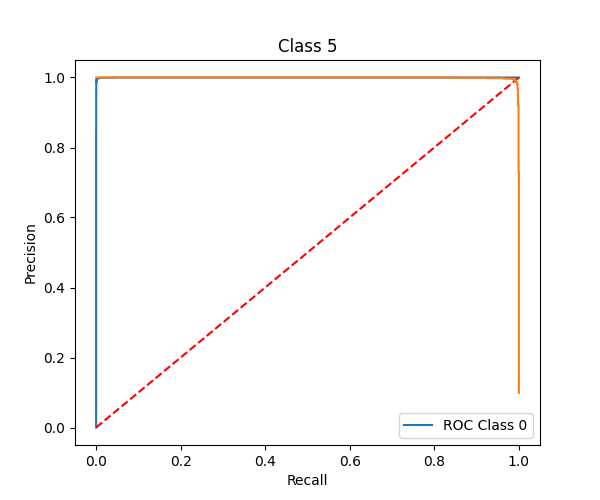

In [26]:
# Precision Recall Curve

precision, recall, thresholds = precision_recall_curve(
    test_label_bin[:,0],
    out_pro[:,0]
)


plt.plot(recall, precision)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Class 5")

plt.grid()

plt.show()

# 29. 🖼️ Visualize Predictions

Several test images are displayed together with their predicted labels.

This provides an intuitive way to visually inspect the CNN's predictions.

Example:

```text
Image → CNN → Predicted Digit
```

Comparing the displayed prediction with the actual image helps identify successful and incorrect classifications.

---


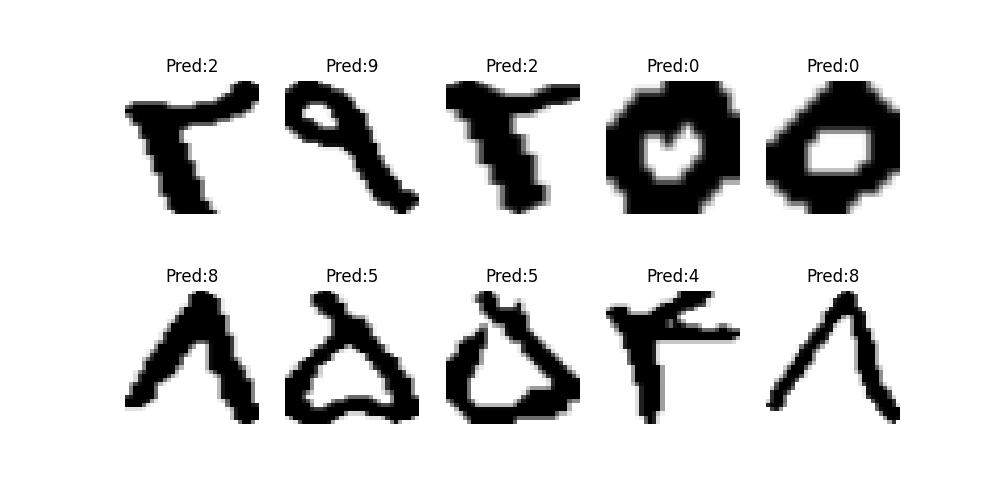

In [27]:
plt.figure(figsize=(10,5))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(x_test[i].reshape(32,32), cmap="gray")

    plt.title(f"Pred:{out[i]}")

    plt.axis("off")

plt.show()

# 30. 🔍 Inspect Individual Predictions

A specific test sample is selected and its raw prediction output is inspected.

This makes it possible to investigate how strongly the model responds to the different digit classes for an individual image.

---

In [28]:
out1 = model.predict(x_test)

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


# 31. 👁️ Visual Inspection of a Test Sample

The selected test image is displayed together with its true label.

This allows direct comparison between:

```text
Actual Label
      vs.
Model Prediction
```

and is useful for manually inspecting individual examples.

---

In [29]:
out1[5]

array([-11.229636 ,   1.7277987, -31.312578 , -26.437073 ,  -3.1336443,
         5.481419 ,  -5.308251 , -32.788563 ,  28.001251 , -10.513259 ],
      dtype=float32)

# 32. 🔢 Multi-Digit Number Recognition

The project goes beyond classifying isolated digits.

A computer-vision pipeline is used to detect individual digits inside an image containing a multi-digit number.

The overall pipeline is:

```text
Input Image
     ↓
Grayscale
     ↓
Blur
     ↓
Thresholding
     ↓
Contour Detection
     ↓
Digit Segmentation
     ↓
Resize to 32 × 32
     ↓
Normalization
     ↓
CNN Prediction
     ↓
Combine Digits
     ↓
Final Number
```

This combines **traditional Computer Vision techniques** with the trained Deep Learning model.

---


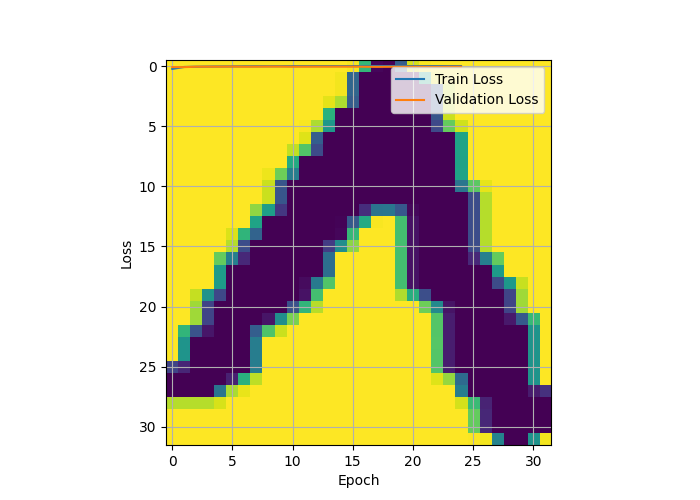

8


In [31]:
plt.close()
plt.imshow(x_test[5])
plt.show()
print(y_test[5])

## 🔢 Multi-Digit Persian Number Recognition

In this section, the trained CNN model is extended from single-digit classification to **multi-digit Persian number recognition**.

The input image may contain multiple digits. The system uses OpenCV to detect and separate individual digits, then passes each digit through the trained CNN model.

### Recognition Pipeline

```text
Input Image
     ↓
Image Loading
     ↓
Grayscale Conversion
     ↓
Image Inversion
     ↓
Gaussian Blur
     ↓
Otsu Thresholding
     ↓
Contour Detection
     ↓
Digit Filtering
     ↓
Sort Digits Left → Right
     ↓
Resize to 32 × 32
     ↓
CNN Prediction
     ↓
Combine Predictions
     ↓
Final Number

In [32]:
from PIL import Image
import numpy as np
import cv2
import matplotlib.pyplot as plt


def recognize_number(path, model):

    # ==============================
    # 1. Read image
    # ==============================

    image = Image.open(path).convert("RGB")
    image = np.array(image)

    # RGB → BGR for OpenCV
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)

    result = image.copy()

    # ==============================
    # 2. Grayscale
    # ==============================

    gray = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2GRAY
    )

    # ==============================
    # 3. Invert
    # ==============================

    gray = cv2.bitwise_not(gray)

    # ==============================
    # 4. Blur
    # ==============================

    blurred = cv2.GaussianBlur(
        gray,
        (5, 5),
        0
    )

    # ==============================
    # 5. Threshold
    # ==============================

    _, binary = cv2.threshold(
        blurred,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    # ==============================
    # 6. Find contours
    # ==============================

    contours, _ = cv2.findContours(
        binary,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    # ==============================
    # 7. Filter digits
    # ==============================

    digits = []

    for contour in contours:

        x, y, w, h = cv2.boundingRect(contour)

        area = w * h

        if w < 8 or h < 8:
            continue

        if area < 50:
            continue

        digits.append(
            (x, y, w, h)
        )

    # ==============================
    # 8. Sort left → right
    # ==============================

    digits.sort(
        key=lambda box: box[0]
    )

    number = ""

    # ==============================
    # 9. Recognize every digit
    # ==============================

    for x, y, w, h in digits:

        digit = binary[
            y:y+h,
            x:x+w
        ]

        digit = cv2.bitwise_not(digit)

        digit = cv2.resize(
            digit,
            (32, 32)
        )

        digit = digit.astype(
            np.float32
        ) / 255.0

        digit = np.expand_dims(
            digit,
            axis=0
        )

        digit = np.expand_dims(
            digit,
            axis=-1
        )

        prediction = model.predict(
            digit,
            verbose=0
        )

        predicted_digit = int(
            np.argmax(prediction[0])
        )

        number += str(
            predicted_digit
        )

        # ==========================
        # Draw result
        # ==========================

        cv2.rectangle(
            result,
            (x, y),
            (x+w, y+h),
            (0, 255, 0),
            2
        )

        cv2.putText(
            result,
            str(predicted_digit),
            (x, max(y - 8, 20)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (0, 255, 0),
            2
        )

    # ==============================
    # 10. Write final number
    # ==============================

    cv2.putText(
        result,
        f"Number: {number}",
        (10, 40),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (0, 0, 255),
        2,
        cv2.LINE_AA
    )

    # ==============================
    # 11. Display
    # ==============================

    plt.figure(figsize=(14, 6))

    plt.imshow(
        cv2.cvtColor(
            result,
            cv2.COLOR_BGR2RGB
        )
    )

    plt.title(
        f"Predicted Number: {number}"
    )

    plt.axis("off")
    plt.show()

    print("Predicted Number:", number)

    return number, result

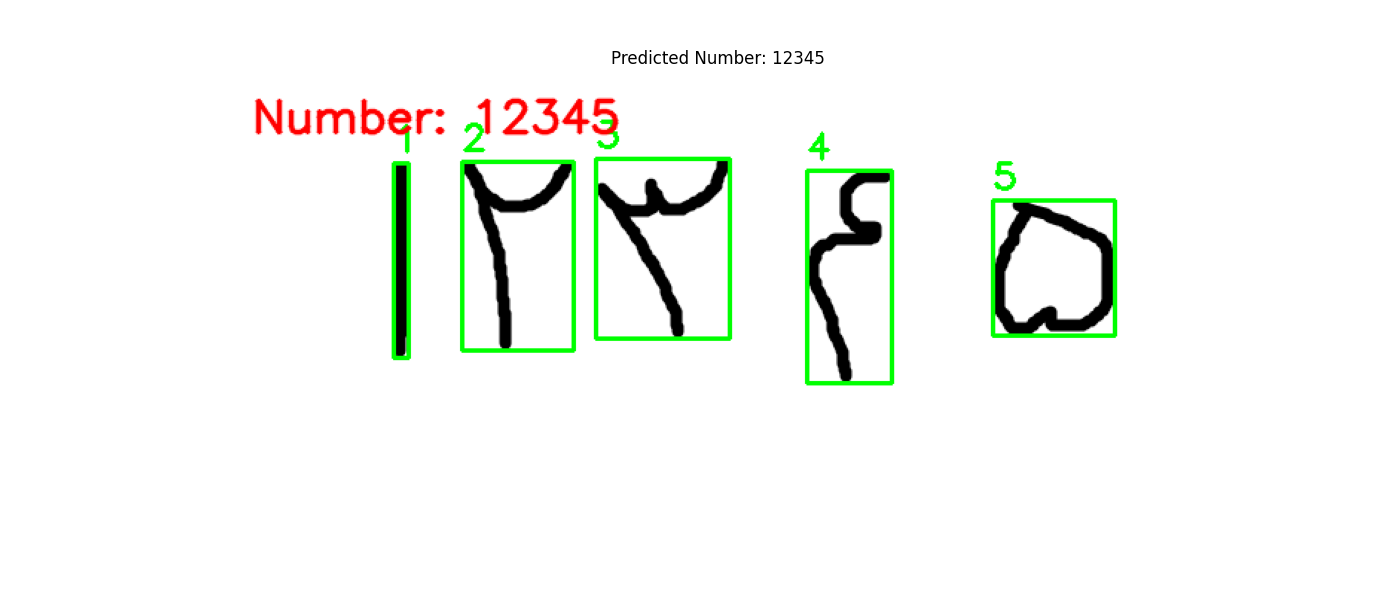

Predicted Number: 12345


In [33]:

path = r"A:\my movies v\هوش مصنوعی\جامع هوش مصنوعی\My project\New folder\25.bmp"

number, result = recognize_number(path, model)

# 👨‍💻 Author

**Mohammad Nahvi**

This project was developed as part of my journey in **Machine Learning, Deep Learning, Computer Vision, and Python development**.
